In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import classification_report
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from xgboost import XGBClassifier

In [3]:
train = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/PCA_26개컬럼.csv")

In [5]:
X_train=train.drop(['Segment'],axis=1)
y=train['Segment']

In [7]:
# 문자열 클래스일 경우 숫자로 변환
le = LabelEncoder()
y = le.fit_transform(y)

In [9]:
# 데이터 분리하기
X_train, X_val, y_train, y_val = train_test_split(X_train, y, test_size=0.2)
print(X_train.shape, X_val.shape, y_val.shape, y_train.shape)

(1920000, 26) (480000, 26) (480000,) (1920000,)


In [11]:
#학습
model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='gpu_hist'
)

model.fit(X_train, y_train)
y_val_train = model.predict(X_val)

In [12]:
# 교차검증
f1_micro = make_scorer(f1_score, average='micro')
scores = cross_val_score(model, X_train, y_train, cv=5, scoring=f1_micro)

In [13]:
print("교차검증 평균 F1:", scores.mean())

교차검증 평균 F1: 0.8732307291666667


In [9]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 300]
}

grid = GridSearchCV(
    estimator=XGBClassifier(objective='multi:softmax', num_class=5, use_label_encoder=False, eval_metric='mlogloss',
                            tree_method="hist", device="cuda"),
    param_grid=param_grid,
    scoring='f1_micro',
    cv=3
)

grid.fit(X_train, y_train)

print("최적 F1:", grid.best_score_)
print("최적 파라미터:", grid.best_params_)

[10:54:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[10:55:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[10:55:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[10:56:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[10:57:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0fdc6d574b9c0d168-1\xgboost\xgboost-ci-windows\src\learner.cc:767: 
Parameters: { "device" } are not used.

[10:58:30] WARNING: 

In [17]:
# 튜닝 결과 반영하여 최종 모델 정의
final_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    learning_rate=0.3,
    max_depth=7,
    n_estimators=300,
    use_label_encoder=False
)

In [19]:
# 전체 훈련 데이터로 학습
final_model.fit(X_train, y_train)

# 검증 데이터 성능 평가
y_val_pred = final_model.predict(X_val)
print("최종 F1 (micro):", f1_score(y_val, y_val_pred, average='micro'))
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

최종 F1 (micro): 0.8793520833333334
              precision    recall  f1-score   support

           A       0.78      0.34      0.47       191
           B       1.00      0.03      0.05        40
           C       0.69      0.55      0.61     25494
           D       0.65      0.56      0.60     69912
           E       0.92      0.96      0.94    384363

    accuracy                           0.88    480000
   macro avg       0.81      0.49      0.54    480000
weighted avg       0.87      0.88      0.87    480000



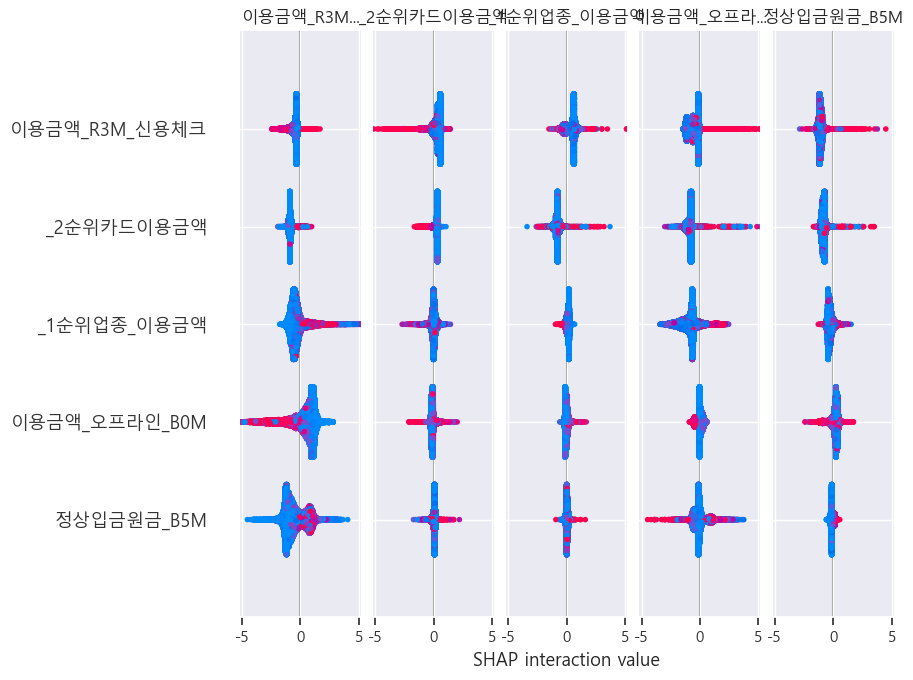

In [16]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer 객체 생성 (최종 모델을 넣어야 함)
explainer = shap.TreeExplainer(final_model)

# 검증 데이터에서 3만개 샘플링
X_sample = X_val.sample(30000, random_state=42)

# 샘플 데이터에 대한 SHAP 값 계산
shap_values = explainer.shap_values(X_sample)

# SHAP 요약 플롯 그리기
shap.summary_plot(shap_values, X_sample)
plt.show()

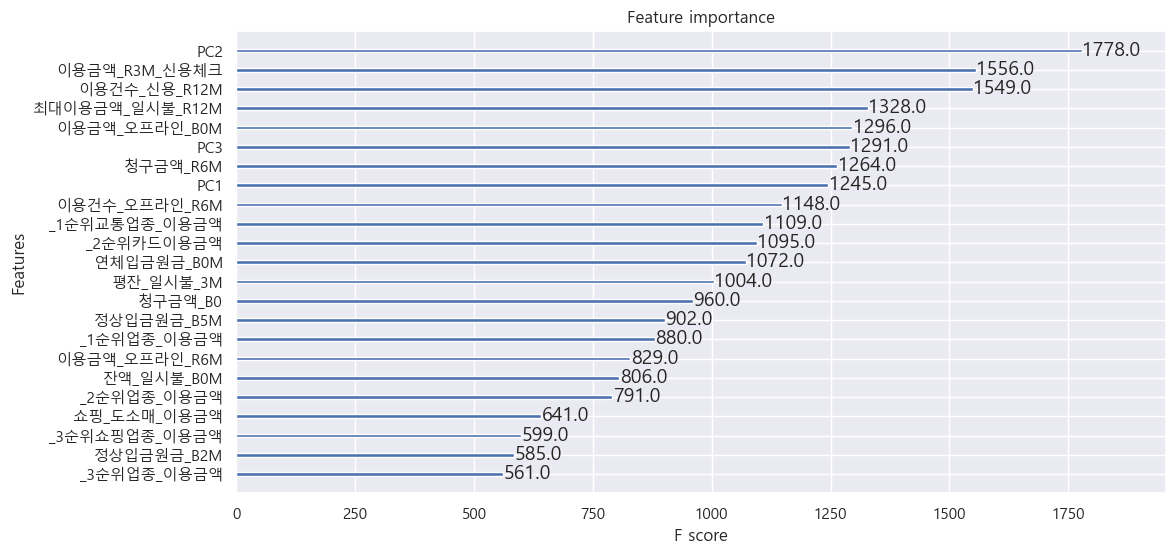

In [17]:
# 피처 중요도 확인 방법
import xgboost as xgb

# 중요도 시각화
xgb.plot_importance(model)
plt.show()

In [18]:
# 중요도 딕셔너리로 추출
# 3가지 지원하지만 그중 'gain'이 가장 의미 있는 기준
# gain은 예측 성능에 가장 크게 기여한 피처 파악 가능함, 해당 피처를 사용해 얻은 정보 이득의 평균

importance_dict = model.get_booster().get_score(importance_type='gain')

# 정렬 및 DataFrame 변환
importance_df = pd.DataFrame(importance_dict.items(), columns=['feature', 'importance'])
importance_df = importance_df.sort_values(by='importance', ascending=False)
print(importance_df.head(15))

            feature  importance
4     이용금액_오프라인_B0M  443.827301
0     이용금액_R3M_신용체크  386.749084
17         청구금액_R6M  294.762665
13     이용건수_신용_R12M   84.002861
7        연체입금원금_B0M   72.955650
3        정상입금원금_B5M   72.623734
6   최대이용금액_일시불_R12M   63.504654
21              PC2   61.672333
9     이용건수_오프라인_R6M   42.249863
1        _2순위카드이용금액   31.997627
15    이용금액_오프라인_R6M   23.936911
16          청구금액_B0   22.230539
18        평잔_일시불_3M   22.230366
5       _2순위업종_이용금액   18.875471
8     _3순위쇼핑업종_이용금액   16.048994


최종 F1 (micro): 0.8793520833333334
              precision    recall  f1-score   support

           A       0.78      0.34      0.47       191
           B       1.00      0.03      0.05        40
           C       0.69      0.55      0.61     25494
           D       0.65      0.56      0.60     69912
           E       0.92      0.96      0.94    384363

    accuracy                           0.88    480000
   macro avg       0.81      0.49      0.54    480000
weighted avg       0.87      0.88      0.87    480000


[클래스별 오분류 수]
실제 A인데 잘못 예측한 개수: 126
실제 B인데 잘못 예측한 개수: 39
실제 C인데 잘못 예측한 개수: 11537
실제 D인데 잘못 예측한 개수: 30454
실제 E인데 잘못 예측한 개수: 15755


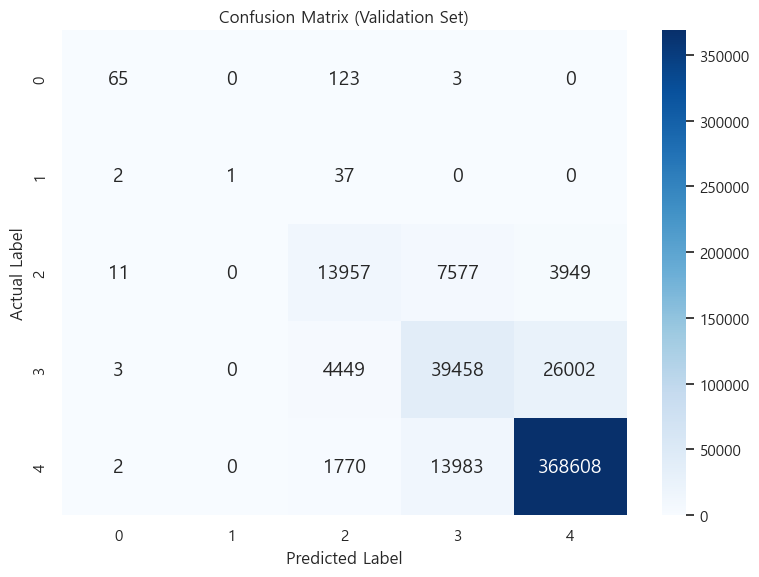

In [21]:
# 디코딩: 정수 라벨 → 클래스 이름 (문자열)
y_val_decoded = le.inverse_transform(y_val)
y_val_pred_decoded = le.inverse_transform(y_val_pred)

# F1 점수 및 리포트 출력
print("최종 F1 (micro):", f1_score(y_val_decoded, y_val_pred_decoded, average='micro'))
print(classification_report(y_val_decoded, y_val_pred_decoded, target_names=le.classes_))

# 혼동행렬
labels_in_val = np.unique(y_val_decoded)
labels = [label for label in le.classes_ if label in labels_in_val]

cm = confusion_matrix(y_val_decoded, y_val_pred_decoded, labels=labels)

# 오분류 수 출력
print("\n[클래스별 오분류 수]")
for i, label in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]
    wrong = total - correct
    print(f"실제 {label}인데 잘못 예측한 개수: {wrong}")

# 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()